In [ ]:
            # --------SelectBest-------#
# SelectKBest method is a filter-based feature selection technique.
# Select the top k most important features based on a statistical test.
# SelectKBest selects the best k features according to a scoring function.

# Process
    # Calculate a score for each feature
    # Rank the features
    # Select the top k features

In [ ]:
# Basic Syntax
# from sklearn.feature_selection import SelectKBest
# from sklearn.feature_selection import score_function
# selector = SelectKBest(score_func=score_function, k=number_of_features) 
# score_func=Statistical test used to rank features

In [ ]:
# Common Score Function

## Chi-Square Test:
# Used for:
    # Categorical features
    # Classification problems
    # from sklearn.feature_selection import chi2
## ANOVA F-test:
# Used for:
    # Numerical features
    # Classification 
    # from sklearn.feature_selection import f_classif
## Correlation:
# Used for:
    # Feature Numeric 
    # Target Numeric
## F-Test for Regression
    # Regression Problem
    # from sklearn.feature_selection import f_regression

In [19]:
# Import Required Libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

In [5]:
# 
Wine_Data=pd.read_csv('wine_data.csv')

In [6]:
# Set column name
Wine_Data.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

In [ ]:
# Show the dataset
Wine_Data.sample(3)

# Input features are numerical and classification problem so use ANOVA test

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
119,2,11.45,2.40,2.42,20.0,96,2.90,2.79,0.32,1.83,3.25,0.80,3.39,625
59,2,12.33,1.10,2.28,16.0,101,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680
112,2,11.41,0.74,2.50,21.0,88,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434


In [8]:
# Extract input and target feature
X=Wine_Data.drop(columns='Class label', axis=1)
y=Wine_Data['Class label']

# Split the dataset into train and test set
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=2
)

In [ ]:
# Select the best 5 feature
selector=SelectKBest(score_func=f_classif, k=5)
selector.fit_transform(X_train, y_train)

Index(['Alcohol', 'Flavanoids', 'Color intensity',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

In [17]:
# Show the top 5 best feature
X_train.columns[selector.get_support()]

Index(['Alcohol', 'Flavanoids', 'Color intensity',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

In [ ]:
# Show the score of each feature
selector.scores_

array([105.5973916 ,  39.17506827,   8.77242403,  27.60640225,
        10.10710044,  70.29105572, 165.24542277,  19.16907116,
        25.94552298, 102.37151601,  73.48226718, 125.94185572,
       168.82879784])

In [20]:
df = pd.read_csv('diabetes.csv')

In [21]:
df.shape

(768, 9)

In [23]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
df.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [25]:
# Create new Feature
df['BloodPressureSquare'] = np.square(df['BloodPressure'])
df['BloodPressureCube'] = df['BloodPressure']**3
df['BloodPressureSqrt'] = np.sqrt(df['BloodPressure'])

In [26]:
df['GlucoseSquare'] = np.square(df['Glucose'])
df['GlucoseCube'] = df['Glucose']**3
df['GlucoseSqrt'] = np.sqrt(df['Glucose'])

In [27]:
df['GlucoseBloodPressure'] = df['BloodPressure'] * df['Glucose']
df['AgeBMI'] = df['Age'] * df['BMI']

In [28]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BloodPressureSquare,BloodPressureCube,BloodPressureSqrt,GlucoseSquare,GlucoseCube,GlucoseSqrt,GlucoseBloodPressure,AgeBMI
0,6,148,72,35,0,33.6,0.627,50,1,5184,373248,8.485281,21904,3241792,12.165525,10656,1680.0
1,1,85,66,29,0,26.6,0.351,31,0,4356,287496,8.124038,7225,614125,9.219544,5610,824.6
2,8,183,64,0,0,23.3,0.672,32,1,4096,262144,8.000000,33489,6128487,13.527749,11712,745.6
3,1,89,66,23,94,28.1,0.167,21,0,4356,287496,8.124038,7921,704969,9.433981,5874,590.1
4,0,137,40,35,168,43.1,2.288,33,1,1600,64000,6.324555,18769,2571353,11.704700,5480,1422.3


In [ ]:
# Extract Numerical Feature
numerical_feature_columns = list(df._get_numeric_data().columns)
numerical_feature_columns

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome',
 'BloodPressureSquare',
 'BloodPressureCube',
 'BloodPressureSqrt',
 'GlucoseSquare',
 'GlucoseCube',
 'GlucoseSqrt',
 'GlucoseBloodPressure',
 'AgeBMI']

<Axes: >

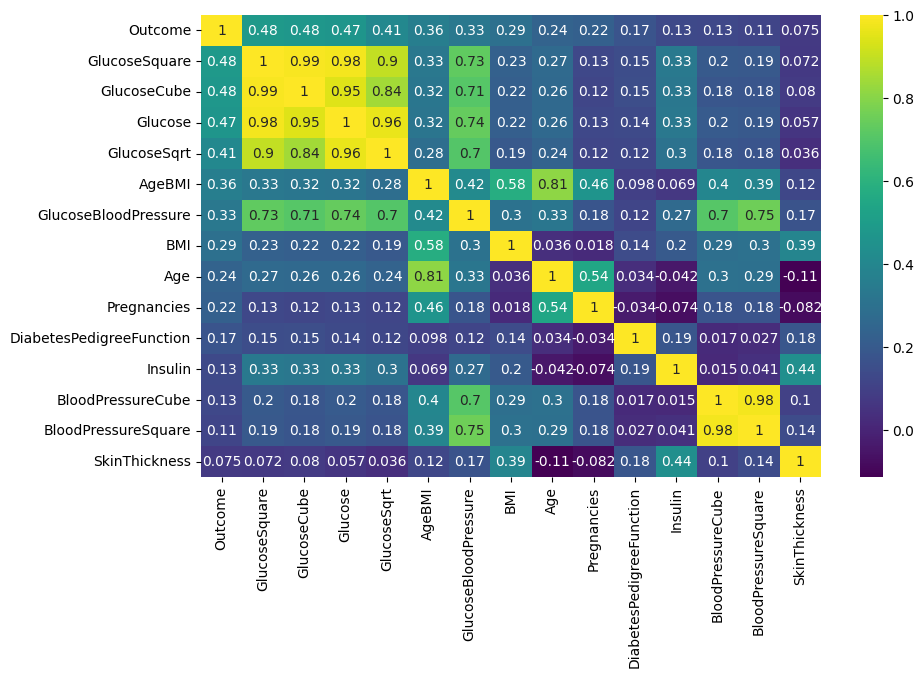

In [34]:
# Draw heatmap
target='Outcome'
k = 15 #number of variables for heatmap
num_df = df[numerical_feature_columns]
corr_matrix = num_df.corr()
target_corr = corr_matrix[target]
top_features = target_corr.nlargest(k)
cols = top_features.index
cm = df[cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, cmap = 'viridis')

In [35]:
X = df.loc[:, df.columns != target]
Y = df.loc[:, df.columns == target]

In [37]:
X.shape
Y.shape

(768, 1)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.33, 
    random_state=8)